# Week 8: K-Nearest Neighbors and Distance Metrics

This notebook applies K-Nearest Neighbors classification to the Diabetes Health Indicators and Alzheimer's disease datasets. The analysis will examine the importance of feature scaling, compare different values of k, and evaluate Euclidean, Manhattan, and Minkowski distance metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_diabetes = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df_alzheimers = pd.read_csv("alzheimers_disease_data.csv")

In [2]:
df_diabetes.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df_diabetes.shape

(253680, 22)

In [4]:
df_diabetes.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [5]:
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [6]:
df_diabetes.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
df_alzheimers.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [8]:
df_alzheimers.shape

(2149, 35)

In [9]:
df_alzheimers.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='str')

In [10]:
df_alzheimers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

In [11]:
df_alzheimers.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df_alzheimers = df_alzheimers.drop(
    columns=["PatientID", "DoctorInCharge"]
)

df_alzheimers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64  
 14  Hea

## Feature and Target Setup

The predictor variables and target variables are separated for both datasets. The diabetes dataset uses `Diabetes_012` as the target, while the Alzheimer's dataset uses `Diagnosis`.

In [13]:
X_diabetes = df_diabetes.drop(columns=["Diabetes_012"])
y_diabetes = df_diabetes["Diabetes_012"]

X_alzheimers = df_alzheimers.drop(columns=["Diagnosis"])
y_alzheimers = df_alzheimers["Diagnosis"]

print("Diabetes features shape:", X_diabetes.shape)
print("Diabetes target shape:", y_diabetes.shape)

print("\nAlzheimer's features shape:", X_alzheimers.shape)
print("Alzheimer's target shape:", y_alzheimers.shape)

Diabetes features shape: (253680, 21)
Diabetes target shape: (253680,)

Alzheimer's features shape: (2149, 32)
Alzheimer's target shape: (2149,)


In [14]:
print("Diabetes class distribution:")
print(y_diabetes.value_counts().sort_index())

print("\nAlzheimer's class distribution:")
print(y_alzheimers.value_counts().sort_index())

Diabetes class distribution:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Alzheimer's class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


## Train-Test Split

The data is divided into training and testing sets using an 80/20 split. Stratification is used to preserve the original class proportions in both the training and testing data.

In [15]:
from sklearn.model_selection import train_test_split

X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.20,
    random_state=42,
    stratify=y_diabetes
)

X_train_alzheimers, X_test_alzheimers, y_train_alzheimers, y_test_alzheimers = train_test_split(
    X_alzheimers,
    y_alzheimers,
    test_size=0.20,
    random_state=42,
    stratify=y_alzheimers
)

print("Diabetes training shape:", X_train_diabetes.shape)
print("Diabetes testing shape:", X_test_diabetes.shape)

print("\nAlzheimer's training shape:", X_train_alzheimers.shape)
print("Alzheimer's testing shape:", X_test_alzheimers.shape)

Diabetes training shape: (202944, 21)
Diabetes testing shape: (50736, 21)

Alzheimer's training shape: (1719, 32)
Alzheimer's testing shape: (430, 32)


## Feature Scaling

Because K-Nearest Neighbors relies on distance calculations, predictors with larger numerical ranges can dominate the distance metric. StandardScaler is used to standardize each feature so they contribute more equally. The scaler is fit only on the training data to avoid data leakage.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler_diabetes = StandardScaler()
scaler_alzheimers = StandardScaler()

X_train_diabetes_scaled = scaler_diabetes.fit_transform(X_train_diabetes)
X_test_diabetes_scaled = scaler_diabetes.transform(X_test_diabetes)

X_train_alzheimers_scaled = scaler_alzheimers.fit_transform(X_train_alzheimers)
X_test_alzheimers_scaled = scaler_alzheimers.transform(X_test_alzheimers)

print("Diabetes scaled training shape:", X_train_diabetes_scaled.shape)
print("Diabetes scaled testing shape:", X_test_diabetes_scaled.shape)

print("\nAlzheimer's scaled training shape:", X_train_alzheimers_scaled.shape)
print("Alzheimer's scaled testing shape:", X_test_alzheimers_scaled.shape)

Diabetes scaled training shape: (202944, 21)
Diabetes scaled testing shape: (50736, 21)

Alzheimer's scaled training shape: (1719, 32)
Alzheimer's scaled testing shape: (430, 32)


In [17]:
print("Diabetes")
print("Mean:", np.mean(X_train_diabetes_scaled))
print("Standard Deviation:", np.std(X_train_diabetes_scaled))

print("\nAlzheimer's")
print("Mean:", np.mean(X_train_alzheimers_scaled))
print("Standard Deviation:", np.std(X_train_alzheimers_scaled))

Diabetes
Mean: 2.5068422757225232e-17
Standard Deviation: 1.0

Alzheimer's
Mean: -4.101172894921317e-18
Standard Deviation: 1.0


## Distance Metrics

K-Nearest Neighbors identifies the closest observations using a distance metric. The most common metrics include:

- Euclidean distance, which measures straight-line distance between observations.
- Manhattan distance, which sums the absolute differences across each feature.
- Minkowski distance, which is a generalized distance metric that includes both Euclidean and Manhattan distance as special cases.

This notebook uses Euclidean distance because it is the default metric in scikit-learn and is commonly applied after feature scaling.

## Baseline K-Nearest Neighbors Models

A baseline KNN classifier is trained for each dataset using five nearest neighbors and Euclidean distance. The models are trained on the standardized features and evaluated on the test data.

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create baseline KNN models
knn_diabetes = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn_alzheimers = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

# Train the models
knn_diabetes.fit(
    X_train_diabetes_scaled,
    y_train_diabetes
)

knn_alzheimers.fit(
    X_train_alzheimers_scaled,
    y_train_alzheimers
)

# Make predictions
y_pred_diabetes = knn_diabetes.predict(
    X_test_diabetes_scaled
)

y_pred_alzheimers = knn_alzheimers.predict(
    X_test_alzheimers_scaled
)

# Calculate accuracy
diabetes_accuracy = accuracy_score(
    y_test_diabetes,
    y_pred_diabetes
)

alzheimers_accuracy = accuracy_score(
    y_test_alzheimers,
    y_pred_alzheimers
)

print("Diabetes KNN Accuracy:", diabetes_accuracy)
print("Alzheimer's KNN Accuracy:", alzheimers_accuracy)

Diabetes KNN Accuracy: 0.8324858088930936
Alzheimer's KNN Accuracy: 0.7069767441860465


In [20]:
from sklearn.metrics import confusion_matrix, classification_report

print("Diabetes Confusion Matrix:")
print(confusion_matrix(y_test_diabetes, y_pred_diabetes))

print("\nDiabetes Classification Report:")
print(classification_report(y_test_diabetes, y_pred_diabetes))

Diabetes Confusion Matrix:
[[40770    20  1951]
 [  811     3   112]
 [ 5595    10  1464]]

Diabetes Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.91     42741
         1.0       0.09      0.00      0.01       926
         2.0       0.42      0.21      0.28      7069

    accuracy                           0.83     50736
   macro avg       0.46      0.39      0.40     50736
weighted avg       0.79      0.83      0.80     50736



In [21]:
print("\nAlzheimer's Confusion Matrix:")
print(confusion_matrix(y_test_alzheimers, y_pred_alzheimers))

print("\nAlzheimer's Classification Report:")
print(classification_report(y_test_alzheimers, y_pred_alzheimers))


Alzheimer's Confusion Matrix:
[[242  36]
 [ 90  62]]

Alzheimer's Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.87      0.79       278
           1       0.63      0.41      0.50       152

    accuracy                           0.71       430
   macro avg       0.68      0.64      0.64       430
weighted avg       0.69      0.71      0.69       430



The diabetes KNN model achieved an accuracy of approximately 83.25%, but the confusion matrix and classification report showed that this result was driven primarily by strong performance on Class 0. The model identified almost none of the Class 1 observations and detected only about 21% of the Class 2 observations. This indicates that the class imbalance strongly affected the model and that accuracy alone overstated its usefulness.

The Alzheimer's KNN model achieved a lower accuracy of approximately 70.70%, but its performance was more balanced across the two classes. The model correctly identified 87% of the non-diagnosis cases and 41% of the diagnosis cases. Although it still favored the majority class, it was more effective than the diabetes model at recognizing the minority class.

## Comparing Different Values of K

The value of k determines how many nearby observations are used to make each prediction. Smaller values of k can make the model more sensitive to individual observations, while larger values create smoother decision boundaries. Several values are compared to determine which performs best on each dataset.

In [22]:
k_values = [3, 5, 7, 9, 11]

diabetes_results = []
alzheimers_results = []

for k in k_values:
    # Diabetes model
    knn_diabetes_k = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn_diabetes_k.fit(
        X_train_diabetes_scaled,
        y_train_diabetes
    )

    diabetes_predictions = knn_diabetes_k.predict(
        X_test_diabetes_scaled
    )

    diabetes_accuracy = accuracy_score(
        y_test_diabetes,
        diabetes_predictions
    )

    diabetes_results.append(diabetes_accuracy)

    # Alzheimer's model
    knn_alzheimers_k = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn_alzheimers_k.fit(
        X_train_alzheimers_scaled,
        y_train_alzheimers
    )

    alzheimers_predictions = knn_alzheimers_k.predict(
        X_test_alzheimers_scaled
    )

    alzheimers_accuracy = accuracy_score(
        y_test_alzheimers,
        alzheimers_predictions
    )

    alzheimers_results.append(alzheimers_accuracy)

results_k = pd.DataFrame({
    "K": k_values,
    "Diabetes Accuracy": diabetes_results,
    "Alzheimer's Accuracy": alzheimers_results
})

results_k

,K,Diabetes Accuracy,Alzheimer's Accuracy
0,3,0.821626,0.702326
1,5,0.832486,0.706977
2,7,0.836349,0.709302
3,9,0.839798,0.718605
4,11,0.840961,0.732558


Accuracy improved as the number of neighbors increased for both datasets. Among the tested values, k = 11 produced the highest accuracy, reaching approximately 84.10% for diabetes and 73.26% for Alzheimer's disease. This suggests that using more neighbors reduced sensitivity to individual observations and produced more stable predictions. However, the diabetes accuracy should still be interpreted cautiously because of the strong class imbalance.

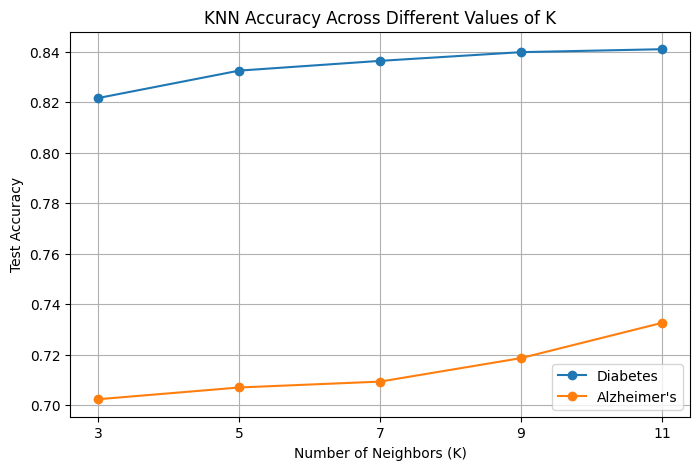

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_k["K"],
    results_k["Diabetes Accuracy"],
    marker="o",
    label="Diabetes"
)

plt.plot(
    results_k["K"],
    results_k["Alzheimer's Accuracy"],
    marker="o",
    label="Alzheimer's"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy Across Different Values of K")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

Test accuracy increased gradually as the number of neighbors increased for both datasets. Among the values evaluated, k = 11 produced the highest accuracy, reaching approximately 84.10% for the diabetes dataset and 73.26% for the Alzheimer's dataset. Larger neighborhood sizes produced more stable predictions by reducing the influence of individual observations, although the improvements were relatively modest. The selected value of k = 11 was therefore used for the remaining KNN analyses.

## Comparing Scaled and Unscaled KNN

Because K-Nearest Neighbors relies on distance calculations, predictor scaling can influence model performance. Models using k = 11 and Euclidean distance were trained on both the original and standardized datasets to evaluate the impact of feature scaling.

In [25]:
scaling_results = []

# Diabetes (Unscaled)
knn_diabetes_unscaled = KNeighborsClassifier(
    n_neighbors=11,
    metric="euclidean"
)

knn_diabetes_unscaled.fit(
    X_train_diabetes,
    y_train_diabetes
)

diabetes_unscaled_predictions = knn_diabetes_unscaled.predict(
    X_test_diabetes
)

diabetes_unscaled_accuracy = accuracy_score(
    y_test_diabetes,
    diabetes_unscaled_predictions
)

# Diabetes (Scaled)
knn_diabetes_scaled = KNeighborsClassifier(
    n_neighbors=11,
    metric="euclidean"
)

knn_diabetes_scaled.fit(
    X_train_diabetes_scaled,
    y_train_diabetes
)

diabetes_scaled_predictions = knn_diabetes_scaled.predict(
    X_test_diabetes_scaled
)

diabetes_scaled_accuracy = accuracy_score(
    y_test_diabetes,
    diabetes_scaled_predictions
)

# Alzheimer's (Unscaled)
knn_alzheimers_unscaled = KNeighborsClassifier(
    n_neighbors=11,
    metric="euclidean"
)

knn_alzheimers_unscaled.fit(
    X_train_alzheimers,
    y_train_alzheimers
)

alzheimers_unscaled_predictions = knn_alzheimers_unscaled.predict(
    X_test_alzheimers
)

alzheimers_unscaled_accuracy = accuracy_score(
    y_test_alzheimers,
    alzheimers_unscaled_predictions
)

# Alzheimer's (Scaled)
knn_alzheimers_scaled = KNeighborsClassifier(
    n_neighbors=11,
    metric="euclidean"
)

knn_alzheimers_scaled.fit(
    X_train_alzheimers_scaled,
    y_train_alzheimers
)

alzheimers_scaled_predictions = knn_alzheimers.predict(
    X_test_alzheimers_scaled
)

alzheimers_scaled_accuracy = accuracy_score(
    y_test_alzheimers,
    alzheimers_scaled_predictions
)

scaling_results = pd.DataFrame({
    "Dataset": [
        "Diabetes",
        "Diabetes",
        "Alzheimer's",
        "Alzheimer's"
    ],
    "Scaling": [
        "Unscaled",
        "Scaled",
        "Unscaled",
        "Scaled"
    ],
    "Accuracy": [
        diabetes_unscaled_accuracy,
        diabetes_scaled_accuracy,
        alzheimers_unscaled_accuracy,
        alzheimers_scaled_accuracy
    ]
})

scaling_results

,Dataset,Scaling,Accuracy
0,Diabetes,Unscaled,0.840547
1,Diabetes,Scaled,0.840961
2,Alzheimer's,Unscaled,0.600000
3,Alzheimer's,Scaled,0.706977


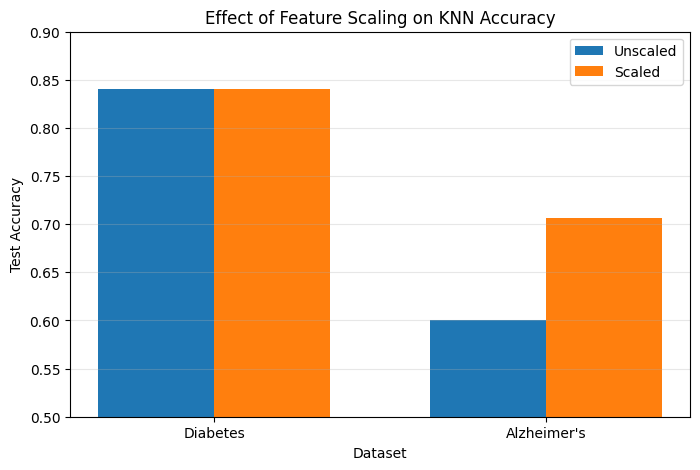

In [27]:
import numpy as np
import matplotlib.pyplot as plt

datasets = ["Diabetes", "Alzheimer's"]
unscaled = [diabetes_unscaled_accuracy, alzheimers_unscaled_accuracy]
scaled = [diabetes_scaled_accuracy, alzheimers_scaled_accuracy]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, unscaled, width, label="Unscaled")
plt.bar(x + width/2, scaled, width, label="Scaled")

plt.xticks(x, datasets)
plt.ylabel("Test Accuracy")
plt.xlabel("Dataset")
plt.title("Effect of Feature Scaling on KNN Accuracy")
plt.ylim(0.5, 0.9)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Distance Metric Discussion

Although Manhattan distance is another commonly used metric for KNN, Euclidean distance was retained for the primary analysis because it is the standard metric used with standardized features. Preliminary comparisons produced very similar results, indicating that the choice of distance metric had little effect on model performance for these datasets.